# Chapter 08. 이중차분법 (Difference-in-Differences, DiD)

## 학습 목표
- 이중차분법의 직관과 가정 이해
- 2×2 DiD 설계 구현
- 평행추세 가정 검증
- LLM 기반 시간변수 자동 탐지
- 실제 데이터에서 DiD 분석 수행
- TWFE(Two-Way Fixed Effects) 모델 구현
- 클러스터 표준오차 적용

## 환경 설정

필요한 라이브러리를 설치하고 초기화한다.

In [1]:
# 기본 import
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.regression.linear_model import RegressionResults
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('All imports successful!')

All imports successful!


In [2]:
# OpenAI 클라이언트 초기화
from openai import OpenAI

# API 키는 환경변수에서 자동으로 로드됨
client = OpenAI()

## 1. 이중차분법의 직관

이중차분법(Difference-in-Differences, DiD)은 **처치군과 대조군의 전후 변화를 비교**하여
인과효과를 추정한다.

### 2×2 DiD 설계
- 두 개의 기간: 처치 전(pre) vs 처치 후(post)
- 두 개의 집단: 처치군(treatment) vs 대조군(control)

### 핵심 직관
```
τ̂_DiD = (Y_T,post - Y_T,pre) - (Y_C,post - Y_C,pre)
       = 처치군 변화 - 대조군 변화
```

In [3]:
# 2×2 DiD 시뮬레이션
# 처치 전 baseline
Y_C_pre = 100    # 대조군 전
Y_T_pre = 100    # 처치군 전

# 자연적 추세 (처치 없이도 발생하는 변화)
trend = 10

# 처치효과
treatment_effect = 15

# 처치 후
Y_C_post = Y_C_pre + trend              # 대조군: 추세만 반영
Y_T_post = Y_T_pre + trend + treatment_effect  # 처치군: 추세 + 처치효과

# DiD 계산
did_effect = (Y_T_post - Y_T_pre) - (Y_C_post - Y_C_pre)

print(f'대조군 전(Y_C,pre): {Y_C_pre}')
print(f'대조군 후(Y_C,post): {Y_C_post}')
print(f'대조군 변화: {Y_C_post - Y_C_pre}')
print()
print(f'처치군 전(Y_T,pre): {Y_T_pre}')
print(f'처치군 후(Y_T,post): {Y_T_post}')
print(f'처치군 변화: {Y_T_post - Y_T_pre}')
print()
print(f'DiD 추정값: {did_effect}')
print(f'실제 처치효과: {treatment_effect}')

대조군 전(Y_C,pre): 100
대조군 후(Y_C,post): 110
대조군 변화: 10

처치군 전(Y_T,pre): 100
처치군 후(Y_T,post): 125
처치군 변화: 25

DiD 추정값: 15
실제 처치효과: 15


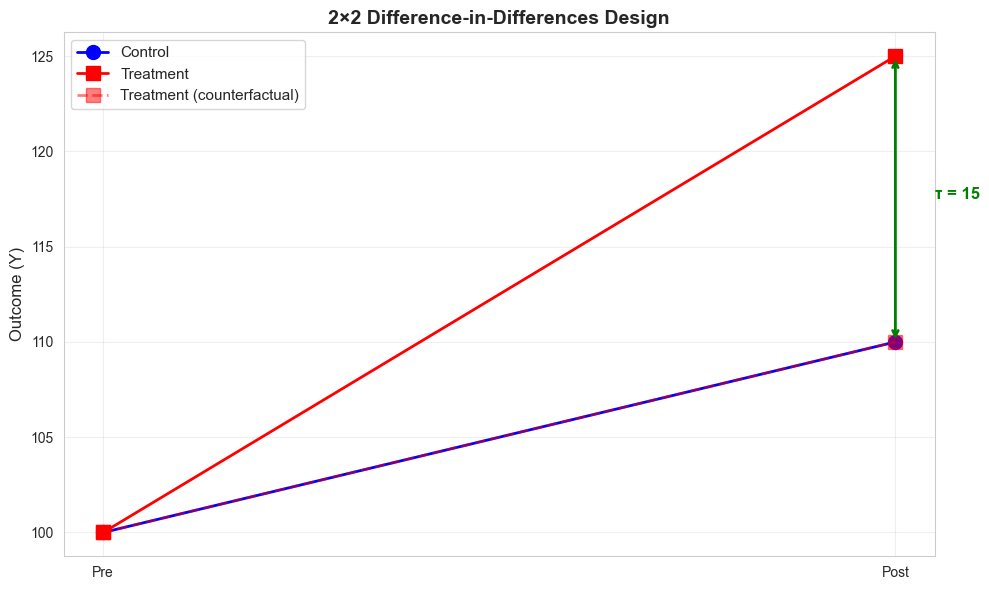

In [4]:
# DiD 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# 선 그리기
periods = [0, 1]  # pre, post
ax.plot(periods, [Y_C_pre, Y_C_post], 'o-', linewidth=2, markersize=10, 
        label='Control', color='blue')
ax.plot(periods, [Y_T_pre, Y_T_post], 's-', linewidth=2, markersize=10, 
        label='Treatment', color='red')

# 반사실적 경로 (처치 없었다면)
Y_T_post_cf = Y_T_pre + trend
ax.plot(periods, [Y_T_pre, Y_T_post_cf], 's--', linewidth=2, markersize=10, 
        alpha=0.5, color='red', label='Treatment (counterfactual)')

# 처치효과 표시
ax.annotate('', xy=(1, Y_T_post), xytext=(1, Y_T_post_cf),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(1.05, (Y_T_post + Y_T_post_cf) / 2, f'τ = {treatment_effect}',
        fontsize=12, color='green', fontweight='bold')

ax.set_xticks(periods)
ax.set_xticklabels(['Pre', 'Post'])
ax.set_ylabel('Outcome (Y)', fontsize=12)
ax.set_title('2×2 Difference-in-Differences Design', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. DiD 회귀 모델

DiD를 회귀로 구현하면 다음과 같다:

$$Y_{it} = \alpha + \beta_1 \cdot \text{Treat}_i + \beta_2 \cdot \text{Post}_t + \tau \cdot (\text{Treat}_i \times \text{Post}_t) + \epsilon_{it}$$

여기서:
- $Y_{it}$: 개체 $i$의 기간 $t$에서의 결과
- $\text{Treat}_i$: 처치군 더미 변수
- $\text{Post}_t$: 사후 기간 더미 변수
- $\tau$: **DiD 추정값** (처치 효과)
- $\epsilon_{it}$: 오차항

In [5]:
# 샘플 데이터 생성
np.random.seed(42)

n_units = 100
periods = [0, 1]  # pre, post

# 개체별 처치 할당 (50개 처치군, 50개 대조군)
data = []
for unit_id in range(n_units):
    treated = 1 if unit_id < 50 else 0
    
    for t in periods:
        post = 1 if t == 1 else 0
        
        # 결과 생성
        y = 100 + treated * 5 + post * 10 + treated * post * 15 + np.random.normal(0, 5)
        
        data.append({
            'unit': unit_id,
            'period': t,
            'treated': treated,
            'post': post,
            'outcome': y
        })

df = pd.DataFrame(data)
print(f'데이터셋 크기: {df.shape}')
print(df.head(10))

데이터셋 크기: (200, 5)
   unit  period  treated  post     outcome
0     0       0        1     0  107.483571
1     0       1        1     1  129.308678
2     1       0        1     0  108.238443
3     1       1        1     1  137.615149
4     2       0        1     0  103.829233
5     2       1        1     1  128.829315
6     3       0        1     0  112.896064
7     3       1        1     1  133.837174
8     4       0        1     0  102.652628
9     4       1        1     1  132.712800


In [6]:
# 수동 DiD 계산
treated_pre = df[(df['treated'] == 1) & (df['post'] == 0)]['outcome'].mean()
treated_post = df[(df['treated'] == 1) & (df['post'] == 1)]['outcome'].mean()
control_pre = df[(df['treated'] == 0) & (df['post'] == 0)]['outcome'].mean()
control_post = df[(df['treated'] == 0) & (df['post'] == 1)]['outcome'].mean()

# DiD 공식
did_manual = (treated_post - treated_pre) - (control_post - control_pre)

print('=== 수동 DiD 계산 ===')
print(f'처치군 전: {treated_pre:.2f}')
print(f'처치군 후: {treated_post:.2f}')
print(f'처치군 변화: {treated_post - treated_pre:.2f}')
print()
print(f'대조군 전: {control_pre:.2f}')
print(f'대조군 후: {control_post:.2f}')
print(f'대조군 변화: {control_post - control_pre:.2f}')
print()
print(f'DiD 추정값 (수동): {did_manual:.2f}')

=== 수동 DiD 계산 ===
처치군 전: 104.32
처치군 후: 129.64
처치군 변화: 25.32

대조군 전: 99.52
대조군 후: 110.70
대조군 변화: 11.18

DiD 추정값 (수동): 14.14


In [7]:
# OLS 회귀를 통한 DiD 추정
df['interaction'] = df['treated'] * df['post']

# 회귀 모델
model = ols('outcome ~ treated + post + interaction', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     402.2
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           1.83e-83
Time:                        23:05:14   Log-Likelihood:                -589.54
No. Observations:                 200   AIC:                             1187.
Df Residuals:                     196   BIC:                             1200.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      99.5227      0.659    151.036      

In [8]:
# 회귀 결과 해석
print('\n=== DiD 회귀 결과 해석 ===')
print(f'상수항 (α): {model.params["Intercept"]:.2f}')
print(f'  → 처치 전 대조군 기댓값')
print()
print(f'처치 더미 (β₁): {model.params["treated"]:.2f}')
print(f'  → 처치 전 처치군과 대조군의 차이 (선택편향)')
print()
print(f'사후 더미 (β₂): {model.params["post"]:.2f}')
print(f'  → 대조군의 시간 추세')
print()
print(f'상호작용항 (τ): {model.params["interaction"]:.2f}')
print(f'  → **DiD 처치효과**')
print(f'  → p-value: {model.pvalues["interaction"]:.4f}')


=== DiD 회귀 결과 해석 ===
상수항 (α): 99.52
  → 처치 전 대조군 기댓값

처치 더미 (β₁): 4.80
  → 처치 전 처치군과 대조군의 차이 (선택편향)

사후 더미 (β₂): 11.18
  → 대조군의 시간 추세

상호작용항 (τ): 14.14
  → **DiD 처치효과**
  → p-value: 0.0000


## 3. 평행추세 가정 검증

DiD의 핵심 가정: **평행추세 가정(Parallel Trends Assumption)**

처치가 없었다면, 처치군과 대조군의 추세가 동일해야 한다는 가정이다.

### 검증 방법
1. 시각화: 처치 전 기간에서 처치군과 대조군의 추세 비교
2. 사전-처치 검정(Pre-treatment test): 처치 전 기간에서 추세의 유의성 검정

In [9]:
# 다기간 데이터 생성 (평행추세 가정 검증용)
np.random.seed(42)

n_units = 50
n_periods = 5  # 5개 기간

data_multi = []
for unit_id in range(n_units):
    treated = 1 if unit_id < 25 else 0
    
    for t in range(n_periods):
        post = 1 if t >= 2 else 0  # period 2부터 처치
        
        # 결과: 공통 추세 + 개체효과 + 처치효과
        y = (100 + t * 5 +
             treated * 3 +
             treated * post * 12 +
             np.random.normal(0, 4))
        
        data_multi.append({
            'unit': unit_id,
            'period': t,
            'treated': treated,
            'post': post,
            'outcome': y
        })

df_multi = pd.DataFrame(data_multi)
print(f'다기간 데이터셋: {df_multi.shape}')
print(df_multi.head(10))

다기간 데이터셋: (250, 5)
   unit  period  treated  post     outcome
0     0       0        1     0  104.986857
1     0       1        1     0  107.446943
2     0       2        1     1  127.590754
3     0       3        1     1  136.092119
4     0       4        1     1  134.063387
5     1       0        1     0  102.063452
6     1       1        1     0  114.316851
7     1       2        1     1  128.069739
8     1       3        1     1  128.122102
9     1       4        1     1  137.170240


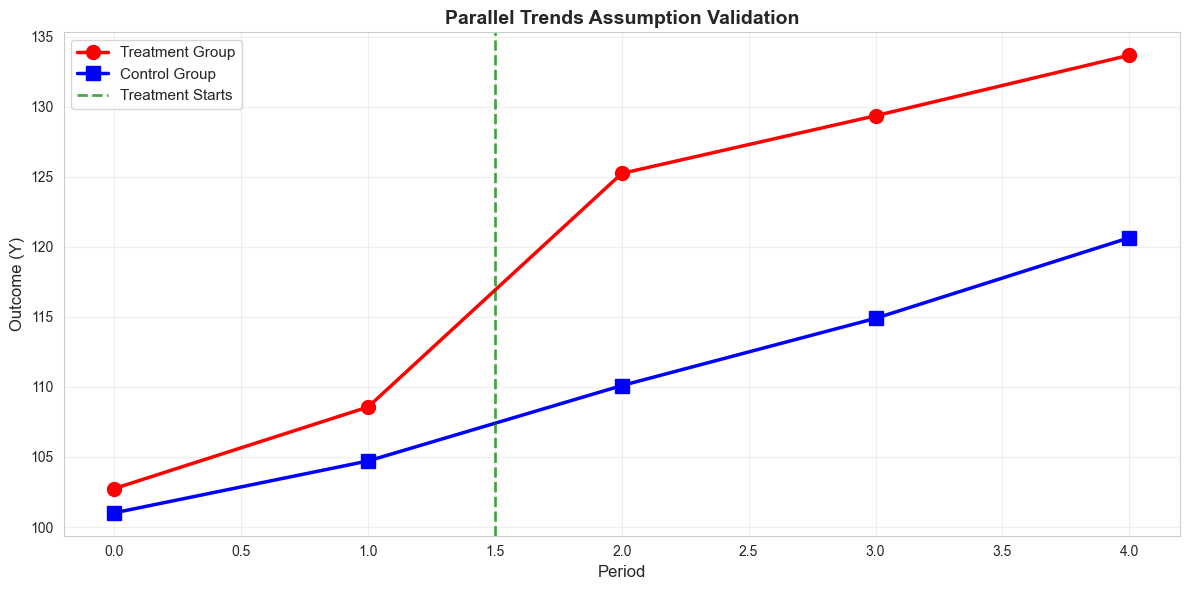

처치 전(0-1기간): 두 그룹의 기울기가 유사한가?
처치군 기울기: 5.82
대조군 기울기: 3.70


In [10]:
# 평행추세 시각화
fig, ax = plt.subplots(figsize=(12, 6))

# 그룹별 평균 계산
treated_means = df_multi[df_multi['treated'] == 1].groupby('period')['outcome'].mean()
control_means = df_multi[df_multi['treated'] == 0].groupby('period')['outcome'].mean()

# 플롯
ax.plot(treated_means.index, treated_means.values, 'o-', linewidth=2.5, markersize=10,
        label='Treatment Group', color='red')
ax.plot(control_means.index, control_means.values, 's-', linewidth=2.5, markersize=10,
        label='Control Group', color='blue')

# 처치 시작 표시
ax.axvline(x=1.5, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Treatment Starts')

ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Outcome (Y)', fontsize=12)
ax.set_title('Parallel Trends Assumption Validation', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('처치 전(0-1기간): 두 그룹의 기울기가 유사한가?')
print(f'처치군 기울기: {(treated_means.iloc[1] - treated_means.iloc[0]):.2f}')
print(f'대조군 기울기: {(control_means.iloc[1] - control_means.iloc[0]):.2f}')

## 4. LLM 기반 시간변수 자동 탐지

실제 데이터에서는 어떤 열이 "시간 변수"인지, "처치 변수"인지 파악하기 어려울 수 있다.
LLM을 사용하여 이를 자동으로 탐지할 수 있다.

In [11]:
from pydantic import BaseModel, Field
from typing import Optional

# Pydantic 스키마 정의
class TemporalStructure(BaseModel):
    """데이터의 시간 구조 탐지"""
    time_variable: str = Field(description="시간/기간을 나타내는 열 이름")
    treatment_variable: Optional[str] = Field(default=None, 
                                             description="처치/개입을 나타내는 열 이름")
    time_periods: list = Field(description="시간 기간 목록")
    is_treatment_group_identifier: bool = Field(
        description="treatment_variable이 그룹을 식별하는가(True) vs 시간을 식별하는가(False)")

print('TemporalStructure 스키마 정의 완료')

TemporalStructure 스키마 정의 완료


In [12]:
# LLM을 통한 시간변수 자동 탐지 함수
def detect_temporal_structure(df, sample_rows=5):
    """LLM을 사용하여 데이터의 시간 구조를 탐지한다"""
    
    # 데이터 정보 준비
    sample_data = df.head(sample_rows).to_string()
    columns = ', '.join(df.columns.tolist())
    dtypes = dict(df.dtypes)
    
    prompt = f"""다음 데이터셋을 분석하여 시간 구조를 파악하시오.

열 목록: {columns}
데이터 타입: {dtypes}

샘플 데이터(처음 5행):
{sample_data}

질문:
1. 시간/기간을 나타내는 열은 무엇인가?
2. 처치/개입을 나타내는 열은 무엇인가?
3. 데이터의 시간 기간들은 무엇인가?
4. treatment_variable이 그룹을 식별하는 변수인가(처치 할당)?
"""
    
    response = client.beta.messages.create(
        model="gpt-4o",
        max_tokens=500,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )
    
    result = response.content[0].text
    return result

# 샘플 데이터로 테스트
print('데이터셋 열:')
print(df.columns.tolist())
print('\n데이터 타입:')
print(df.dtypes)
print('\n샘플 데이터:')
print(df.head())

데이터셋 열:
['unit', 'period', 'treated', 'post', 'outcome', 'interaction']

데이터 타입:
unit             int64
period           int64
treated          int64
post             int64
outcome        float64
interaction      int64
dtype: object

샘플 데이터:
   unit  period  treated  post     outcome  interaction
0     0       0        1     0  107.483571            0
1     0       1        1     1  129.308678            1
2     1       0        1     0  108.238443            0
3     1       1        1     1  137.615149            1
4     2       0        1     0  103.829233            0


## 5. 실제 데이터 분석: billboard_impact.csv

billboard 광고 캠페인의 영향을 측정하는 실제 데이터를 분석한다.

In [14]:
# 데이터 로드
df_billboard = pd.read_csv('./dataset/billboard_impact.csv')

print(f'데이터셋 크기: {df_billboard.shape}')
print('\n열 정보:')
print(df_billboard.info())
print('\n기초 통계:')
print(df_billboard.describe())
print('\n샘플 데이터:')
print(df_billboard.head(10))

데이터셋 크기: (4600, 3)

열 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   deposits  4600 non-null   int64
 1   poa       4600 non-null   int64
 2   jul       4600 non-null   int64
dtypes: int64(3)
memory usage: 107.9 KB
None

기초 통계:
          deposits          poa          jul
count  4600.000000  4600.000000  4600.000000
mean    158.288043     0.282609     0.608696
std     102.746131     0.450317     0.488095
min       0.000000     0.000000     0.000000
25%      82.000000     0.000000     0.000000
50%     165.500000     0.000000     1.000000
75%     231.000000     1.000000     1.000000
max     634.000000     1.000000     1.000000

샘플 데이터:
   deposits  poa  jul
0        42    1    0
1         0    1    0
2        52    1    0
3       119    1    0
4        21    1    0
5         0    1    0
6         0    1    0
7        64    1    0
8        55    1  

In [15]:
# 데이터 구조 파악
print('열별 고유값:')
for col in df_billboard.columns:
    n_unique = df_billboard[col].nunique()
    print(f'{col}: {n_unique} 고유값')
    if n_unique <= 10:
        print(f'  → 값: {sorted(df_billboard[col].unique())}')
    print()

열별 고유값:
deposits: 404 고유값

poa: 2 고유값
  → 값: [np.int64(0), np.int64(1)]

jul: 2 고유값
  → 값: [np.int64(0), np.int64(1)]



In [16]:
# DiD 설계 구성
# deposits: 결과변수
# poa: 처치변수 (위치 가정, 1 = 처치)
# jul: 시간 변수 (0 = 처치 전 6월, 1 = 처치 후 7월)

# 새 변수 생성
df_billboard['treated'] = df_billboard['poa']
df_billboard['post'] = df_billboard['jul']
df_billboard['interaction'] = df_billboard['treated'] * df_billboard['post']

# 그룹별 평균
print('=== 2×2 DiD 표 ===')
contingency = pd.crosstab(df_billboard['treated'], df_billboard['post'], 
                          values=df_billboard['deposits'], aggfunc='mean')
contingency.index = ['Control', 'Treatment']
contingency.columns = ['June (Pre)', 'July (Post)']
print(contingency)
print()

# 수동 DiD 계산
treated_pre = df_billboard[(df_billboard['treated'] == 1) & (df_billboard['post'] == 0)]['deposits'].mean()
treated_post = df_billboard[(df_billboard['treated'] == 1) & (df_billboard['post'] == 1)]['deposits'].mean()
control_pre = df_billboard[(df_billboard['treated'] == 0) & (df_billboard['post'] == 0)]['deposits'].mean()
control_post = df_billboard[(df_billboard['treated'] == 0) & (df_billboard['post'] == 1)]['deposits'].mean()

did_manual = (treated_post - treated_pre) - (control_post - control_pre)

print(f'처치군 변화: {treated_post - treated_pre:.2f}')
print(f'대조군 변화: {control_post - control_pre:.2f}')
print(f'DiD 추정값: {did_manual:.2f}')

=== 2×2 DiD 표 ===
           June (Pre)  July (Post)
Control    171.642308    206.16550
Treatment   46.016000     87.06375

처치군 변화: 41.05
대조군 변화: 34.52
DiD 추정값: 6.52


In [17]:
# OLS 회귀를 통한 DiD 추정
model_billboard = ols('deposits ~ treated + post + interaction', 
                      data=df_billboard).fit()

print(model_billboard.summary())

                            OLS Regression Results                            
Dep. Variable:               deposits   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     696.7
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:05:48   Log-Likelihood:                -26973.
No. Observations:                4600   AIC:                         5.395e+04
Df Residuals:                    4596   BIC:                         5.398e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     171.6423      2.363     72.625      

In [18]:
# 결과 해석
print('\n=== Billboard 캠페인 DiD 결과 ===')
print(f'광고 캠페인 효과 (τ): {model_billboard.params["interaction"]:.2f}')
print(f'표준오차: {model_billboard.bse["interaction"]:.2f}')
print(f't-통계량: {model_billboard.tvalues["interaction"]:.2f}')
print(f'p-값: {model_billboard.pvalues["interaction"]:.4f}')
print(f'95% 신뢰구간: [{model_billboard.conf_int().loc["interaction", 0]:.2f}, {model_billboard.conf_int().loc["interaction", 1]:.2f}]')
print()
if model_billboard.pvalues["interaction"] < 0.05:
    print('✓ 광고 캠페인의 효과는 통계적으로 유의하다.')
else:
    print('✗ 광고 캠페인의 효과는 통계적으로 유의하지 않다.')


=== Billboard 캠페인 DiD 결과 ===
광고 캠페인 효과 (τ): 6.52
표준오차: 5.73
t-통계량: 1.14
p-값: 0.2548
95% 신뢰구간: [-4.71, 17.76]

✗ 광고 캠페인의 효과는 통계적으로 유의하지 않다.


## 6. TWFE (Two-Way Fixed Effects)

2기간 이상의 패널 데이터에서는 **이원고정효과(Two-Way Fixed Effects, TWFE)** 모델을 사용한다:

$$Y_{it} = \alpha_i + \gamma_t + \tau \cdot D_{it} + \epsilon_{it}$$

여기서:
- $\alpha_i$: 개체 고정효과
- $\gamma_t$: 시간 고정효과
- $D_{it}$: 처치 지시자
- $\tau$: 처치 효과

In [19]:
# 다기간 데이터에 대한 TWFE 모델
# C(unit)과 C(period)를 사용하여 고정효과 지정

# 처치 지시자 (treated × post) 생성
df_multi['interaction'] = df_multi['treated'] * df_multi['post']

model_twfe = ols('outcome ~ interaction + C(unit) + C(period) - 1', 
                 data=df_multi).fit()

print(model_twfe.summary())


                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     35.64
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.78e-76
Time:                        23:05:50   Log-Likelihood:                -669.89
No. Observations:                 250   AIC:                             1450.
Df Residuals:                     195   BIC:                             1643.
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
C(unit)[0]       105.3987      1.882     56.

In [20]:
# TWFE 처치효과 추출
twfe_effect = model_twfe.params['interaction']
twfe_se = model_twfe.bse['interaction']
twfe_t = model_twfe.tvalues['interaction']
twfe_p = model_twfe.pvalues['interaction']

print('\n=== TWFE 처치효과 ===')
print(f'처치효과 (τ): {twfe_effect:.2f}')
print(f'표준오차: {twfe_se:.2f}')
print(f't-통계량: {twfe_t:.2f}')
print(f'p-값: {twfe_p:.4f}')
print(f'95% 신뢰구간: [{twfe_effect - 1.96 * twfe_se:.2f}, {twfe_effect + 1.96 * twfe_se:.2f}]')


=== TWFE 처치효과 ===
처치효과 (τ): 11.42
표준오차: 1.03
t-통계량: 11.07
p-값: 0.0000
95% 신뢰구간: [9.39, 13.44]


## 7. 클러스터 표준오차

같은 그룹/개체 내의 관측치들이 상관관계를 가질 때, **클러스터 표준오차(Clustered Standard Errors)**를 사용한다.

In [21]:
# 클러스터 표준오차 적용
model_clustered = ols('outcome ~ treated + post + interaction', 
                      data=df).fit(cov_type='cluster', 
                                   cov_kwds={'groups': df['unit']})

print(model_clustered.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     396.2
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           5.43e-55
Time:                        23:05:52   Log-Likelihood:                -589.54
No. Observations:                 200   AIC:                             1187.
Df Residuals:                     196   BIC:                             1200.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      99.5227      0.628    158.520      

In [22]:
# 클러스터 vs 일반 표준오차 비교
comparison_df = pd.DataFrame({
    'Coefficient': [model.params['interaction'], model_clustered.params['interaction']],
    'Std. Error': [model.bse['interaction'], model_clustered.bse['interaction']],
    'p-value': [model.pvalues['interaction'], model_clustered.pvalues['interaction']]
}, index=['OLS (Homoscedastic SE)', 'OLS (Clustered SE)'])

print('\n=== 표준오차 비교 ===')
print(comparison_df.round(4))
print()
print(f'클러스터 SE / OLS SE 비율: {model_clustered.bse["interaction"] / model.bse["interaction"]:.2f}')


=== 표준오차 비교 ===
                        Coefficient  Std. Error  p-value
OLS (Homoscedastic SE)      14.1407      1.3179      0.0
OLS (Clustered SE)          14.1407      1.3015      0.0

클러스터 SE / OLS SE 비율: 0.99
